# Solving the Canoe problem with compositional Hamilton Jacobi Reachability

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

from IPython.display import HTML
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import hj_reachability as hj
import pandas as pd

from scipy import integrate as ode
import canoe

import random
random.seed(123)

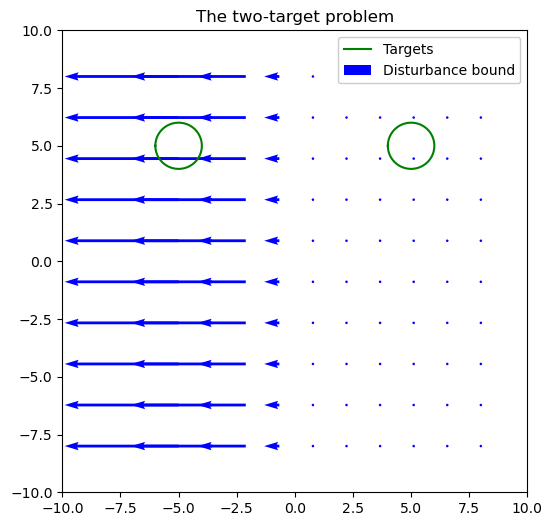

In [2]:
fig, ax = plt.subplots(figsize = (6,6))

thetas = np.linspace(-np.pi,np.pi,100)
ax.plot(5 + np.cos(thetas), 5 + np.sin(thetas), color = 'g', label = 'Targets')
ax.plot(-5 + np.cos(thetas), 5 + np.sin(thetas), color = 'g')


# Meshgrid 
x, y = np.meshgrid(np.linspace(-5, 8, 10),  
                   np.linspace(-8, 8, 10)) 
  
# Directional vectors 
u = np.minimum(x/4.0,0.0*x)
v = 0.0 * y
  
# Plotting Vector Field with QUIVER 
plt.quiver(x, y, u, v, color='b', label = 'Disturbance bound') 
plt.title('The two-target problem') 

ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.legend(framealpha = 1.0)

plt.savefig("/Users/dylanhirsch/Desktop/two_target.png", dpi=300, bbox_inches='tight')

# Step 0: Setup

In [3]:
t0 = -17.5

# Step 1: Solve optimal control problem for first target

In [4]:
dynamics = canoe.canoe()
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(hj.sets.Box(np.array([-10.,-10.]),
                                                                           np.array([10., 10.])),
                                                               (100, 100),
                                                               periodic_dims=None)
l1 = np.linalg.norm(grid.states[...,[0,1]] - np.array([5.,5.]), axis = -1) - 1.

solver_settings = hj.SolverSettings.with_accuracy("very_high",
                                                  hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

In [5]:
time = 0.
times = np.linspace(0., t0, 100)
V1 = hj.solve(solver_settings, dynamics, grid, times, l1)

In [6]:
vmin, vmax = V1.min(), V1.max()
levels = np.linspace(round(vmin), round(vmax), round(vmax) - round(vmin) + 1)
fig = plt.figure(figsize=(13, 8))

def render_frame(i, colorbar=False):
    plt.contourf(grid.coordinate_vectors[0],
                 grid.coordinate_vectors[1],
                 V1[i, :, :].T,
                 vmin=vmin,
                 vmax=vmax,
                 levels=levels)
    if colorbar:
        plt.colorbar()
    plt.contour(grid.coordinate_vectors[0],
            grid.coordinate_vectors[1],
            V1[-1, :,:].T,
            levels=0,
            colors="black",
            linewidths=3)


render_frame(0, True)
animation = anim.FuncAnimation(fig, render_frame, V1.shape[0], interval=50)
writervideo = anim.FFMpegWriter(fps=60)
animation.save('right_target.mp4', writer=writervideo)
animation = HTML(anim.FuncAnimation(fig, render_frame, V1.shape[0], interval=50).to_html5_video())
plt.close(); animation

100%|#################################| 17.5000/17.5 [00:00<00:00, 52.17sim_s/s]


# Step 2: Solve Optimal control problem for the second target

In [7]:
l2 = np.linalg.norm(grid.states[...,[0,1]] - np.array([-5,5]), axis = -1) - 1
    
solver_settings = hj.SolverSettings.with_accuracy("very_high",
                                                  hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

In [8]:
V2 = hj.solve(solver_settings, dynamics, grid, times, l2)

  0%|                                         |  0.0000/17.5 [00:00<?, ?sim_s/s]

In [9]:
vmin, vmax = V2.min(), V2.max()
levels = np.linspace(round(vmin), round(vmax), round(vmax) - round(vmin) + 1)
fig = plt.figure(figsize=(13, 8))

def render_frame(i, colorbar=False):
    plt.contourf(grid.coordinate_vectors[0],
                 grid.coordinate_vectors[1],
                 V2[i, :, :].T,
                 vmin=vmin,
                 vmax=vmax,
                 levels=levels)
    if colorbar:
        plt.colorbar()
    plt.contour(grid.coordinate_vectors[0],
            grid.coordinate_vectors[1],
            V2[-1, :,:].T,
            levels=0,
            colors="black",
            linewidths=3)


render_frame(0, True)
animation = anim.FuncAnimation(fig, render_frame, V1.shape[0], interval=50)
writervideo = anim.FFMpegWriter(fps=60)
animation.save('left_target.mp4', writer=writervideo)
animation = HTML(anim.FuncAnimation(fig, render_frame, V1.shape[0], interval=50).to_html5_video())
plt.close(); animation

100%|#################################| 17.5000/17.5 [00:00<00:00, 58.23sim_s/s]


# Optimal control problem for reaching the targets in either order

In [10]:
def value_postprocessor(t, v, V1 = V1, V2 = V2, times = times, l1 = l1, l2 = l2):
    i = jnp.argmin(jnp.abs(t - times)) 
    return jnp.minimum(v, jnp.minimum(jnp.maximum(l2, V1[i,...]), jnp.maximum(l1, V2[i,...])))
    
solver_settings = hj.SolverSettings.with_accuracy("very_high",
                                                 value_postprocessor = value_postprocessor)
V = hj.solve(solver_settings, dynamics, grid, times, jnp.maximum(l1,l2))

vmin, vmax = V.min(), V.max()
levels = np.linspace(round(vmin), round(vmax), round(vmax) - round(vmin) + 1)
fig = plt.figure(figsize=(13, 8))

def render_frame(i, colorbar=False):
    plt.contourf(grid.coordinate_vectors[0],
                 grid.coordinate_vectors[1],
                 V[i, :, :].T,
                 vmin=vmin,
                 vmax=vmax,
                 levels=levels)
    if colorbar:
        plt.colorbar()
    plt.contour(grid.coordinate_vectors[0],
            grid.coordinate_vectors[1],
            V[-1, :,:].T,
            levels=0,
            colors="black",
            linewidths=3)


render_frame(0, True)
animation = anim.FuncAnimation(fig, render_frame, V1.shape[0], interval=50)
writervideo = anim.FFMpegWriter(fps=60)
animation.save('two_target_value_function.mp4', writer=writervideo)
animation = HTML(animation.to_html5_video())
plt.close(); animation

100%|#################################| 17.5000/17.5 [00:00<00:00, 56.59sim_s/s]


In [11]:
t = -17
i = np.argmin(abs(t - times))
print(grid.interpolate(V[i,...], state = (4,5)))
print(grid.interpolate(V[i,...], state = (5,5)))

-0.9364072
-0.9364115


# Plot optimal trajectory

In [12]:
def model(t, x, grad_valuess, grid, dynamics, times):
    i = np.argmin(np.abs(times - t))

    grad_value = grid.interpolate(grad_valuess[i], state = x)
    
    u = dynamics.optimal_control(x, t, grad_value)
    d = dynamics.optimal_disturbance(x, t, grad_value)
    fx = dynamics.open_loop_dynamics(x, t)
    Bu = dynamics.control_jacobian(x,t)
    Bd = dynamics.disturbance_jacobian(x,t)
    
    dx = fx + Bu @ u + Bd @ d;
    dx = dx.tolist()
    return dx

def characteristic(t0, x0, values, grid, dynamics, times):
    grad_valuess = [grid.grad_values(values[i,...]) for i in range(len(times))]
    sol = ode.solve_ivp(lambda t,x:model(t, x, grad_valuess, grid, dynamics, times), [t0 ,0], x0, max_step = .1)
    return sol

In [13]:
sol = characteristic(t0, [0.0,0.0], V, grid, dynamics, times)

l1s = np.array([grid.interpolate(l1, state = sol.y[:,i]) for i in range(len(sol.t))])
l2s = np.array([grid.interpolate(l2, state = sol.y[:,i]) for i in range(len(sol.t))])

i1 = np.argmax(l1s < -.5) if any(l1s < 0) else np.inf
i2 = np.argmax(l2s < -.5) if any(l2s < 0) else np.inf

if i1 < i2:
    newsol  = characteristic(sol.t[i1], sol.y[:,i1], V2, grid, dynamics, times)
else:
    newsol  = characteristic(sol.t[i2], sol.y[:,i2], V1, grid, dynamics, times)

i = min(i1,i2)
ts = np.concatenate([sol.t[:i], newsol.t[i:]])
ys = np.concatenate([sol.y[:,:i], newsol.y[:,i:]], axis = 1)

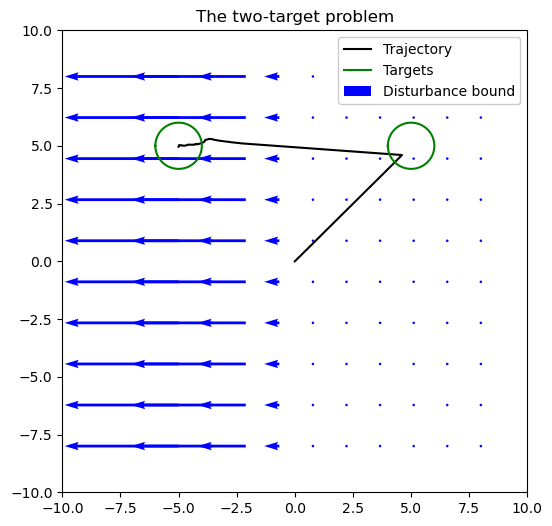

In [17]:
fig, ax = plt.subplots(figsize = (6,6))
ax.plot(ys[0,:], ys[1,:], color = 'k', label = 'Trajectory')

thetas = np.linspace(-np.pi,np.pi,100)
ax.plot(5 + np.cos(thetas), 5 + np.sin(thetas), color = 'g', label = 'Targets')
ax.plot(-5 + np.cos(thetas), 5 + np.sin(thetas), color = 'g')


# Meshgrid 
x, y = np.meshgrid(np.linspace(-5, 8, 10),  
                   np.linspace(-8, 8, 10)) 
  
# Directional vectors 
u = np.minimum(x/4.0,0.0*x)
v = 0.0 * y
  
# Plotting Vector Field with QUIVER 
plt.quiver(x, y, u, v, color='b', label = 'Disturbance bound') 
plt.title('The two-target problem') 

ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.legend(framealpha = 1.0)


plt.savefig("/Users/dylanhirsch/Desktop/two_target_soln.png", dpi=300, bbox_inches='tight')